# Excersize 1: Markov chain

Write a code to analyze a discrete-time Markov Chain with 5 states (S = (0,1,2,3,4)) using 2 methods.

**Method 1**: Stochastic Simulation

Simulate the chain for large $n$ steps by randomly picking the next state based on the transition probabilities.

Tasks:
*	Plot a frequence of the state occurrences.
*	Calculate the **theoretical steady-state probability** and compare the simulated result with the theoretical value.
*	Determine the **final mean observable** and compare the simulated result with the theoretical value.

**Method 2**: Matrix Iteration

Use the formula
$P_{t+1} = P_t \times T$ or $P_{t+1} = T^T \times P_t$ where $P_{t}$ is the probability disttribution vector at the step t. 

*	Compare the resulting distribution and mean observable with the results from Method 1.
*	Why is the final distribution uniform ?
The transition probabilities are defined as:

$T(s_i \rightarrow s_j) = 1/3$ if $j=i\pm 1$ or $j =i$. 


Transition matrix T:
[[0.6667 0.3333 0.     0.     0.    ]
 [0.3333 0.3333 0.3333 0.     0.    ]
 [0.     0.3333 0.3333 0.3333 0.    ]
 [0.     0.     0.3333 0.3333 0.3333]
 [0.     0.     0.     0.3333 0.6667]]


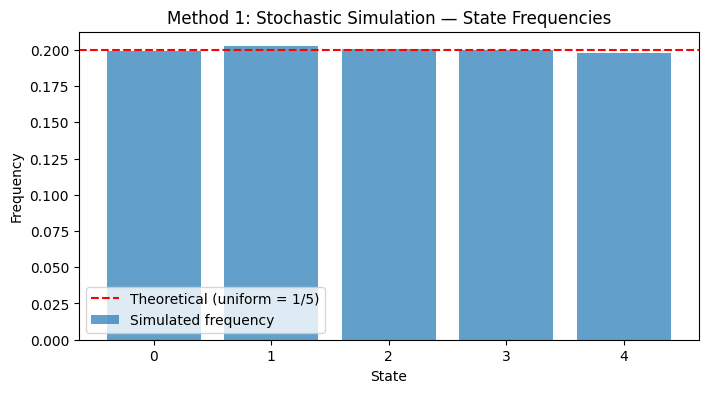


Simulated steady-state:   [0.1988 0.2024 0.2007 0.2001 0.198 ]
Theoretical steady-state: [0.2 0.2 0.2 0.2 0.2]

Simulated mean observable:    1.9960
Theoretical mean observable:  2.0000


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# The transition matrix
N_states = 5
T = np.zeros((N_states, N_states))

for i in range(N_states):
    if i > 0:
        T[i, i - 1] = 1.0 / 3.0
    if i < N_states - 1:
        T[i, i + 1] = 1.0 / 3.0
        
    T[i, i] = 1.0 - sum(T[i, j] for j in range(N_states) if j != i)

print("Transition matrix T:")
print(np.round(T, 4))

#M ethod 1: Stochastic Simulation
n_steps = 100000
state = np.random.randint(0, N_states)  # random initial state
trajectory = [state]

for _ in range(n_steps - 1):
    state = np.random.choice(N_states, p=T[state])
    trajectory.append(state)

trajectory = np.array(trajectory)

# Frequency of state occurrences
counts = np.bincount(trajectory, minlength=N_states)
sim_freq = counts / n_steps

plt.figure(figsize=(8, 4))
plt.bar(range(N_states), sim_freq, alpha=0.7, label='Simulated frequency')
plt.axhline(1/N_states, color='red', linestyle='--', label='Theoretical (uniform = 1/5)')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Method 1: Stochastic Simulation — State Frequencies')
plt.legend()
plt.show()

# Theoretical steady-state: uniform for this symmetric chain
pi_theory = np.ones(N_states) / N_states

print("\nSimulated steady-state:  ", np.round(sim_freq, 4))
print("Theoretical steady-state:", np.round(pi_theory, 4))

# Observable value of the state (0, 1, 2, 3, 4)
observable = np.arange(N_states)
sim_mean = np.mean(trajectory)
theory_mean = np.dot(pi_theory, observable)

print(f"\nSimulated mean observable:    {sim_mean:.4f}")
print(f"Theoretical mean observable:  {theory_mean:.4f}")


Final distribution after matrix iteration:
[0.2 0.2 0.2 0.2 0.2]
Final mean observable (matrix): 2.0000
Theoretical mean observable:    2.0000


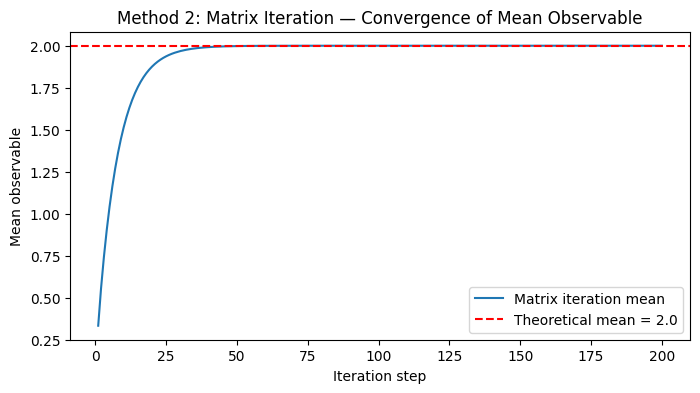

In [40]:
#Method 2: Matrix Iteration
n_iter = 200
P = np.zeros(N_states)
P[0] = 1.0  # start in state 0

means_iter = []
for _ in range(n_iter):
    P = P @ T  # P_{t+1} = P_t * T
    means_iter.append(np.dot(P, observable))

print("Final distribution after matrix iteration:")
print(np.round(P, 6))
print(f"Final mean observable (matrix): {means_iter[-1]:.4f}")
print(f"Theoretical mean observable:    {theory_mean:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_iter + 1), means_iter, label='Matrix iteration mean')
plt.axhline(theory_mean, color='red', linestyle='--', label=f'Theoretical mean = {theory_mean}')
plt.xlabel('Iteration step')
plt.ylabel('Mean observable')
plt.title('Method 2: Matrix Iteration — Convergence of Mean Observable')
plt.legend()
plt.show()


### Exercise 1 Discussion

**Why is the final distribution uniform?**

The transition probabilities are defined symmetrically: each state $s_i$ can transition to itself or to its immediate neighbors with equal probability $1/3$. This means the chain is:

- **Irreducible**: every state can be reached from every other state.
- **Aperiodic**: due to the self-loops, the chain does not oscillate.
- **Doubly stochastic**: each column of the transition matrix sums to 1, just like each row.

For a doubly stochastic transition matrix on $N$ states, the unique stationary distribution is the **uniform distribution** $\pi_i = 1/N$.

Both methods confirm this: after a sufficient number of steps, the simulated frequency and the matrix iteration both converge to $\pi_i = 0.2$ for all states, and the mean observable converges to $\bar{s} = 2$.

#### Final conclusion

Both the stochastic simulation and the matrix iteration method reproduce the theoretical steady-state distribution. The convergence speed depends on the spectral gap of the transition matrix — the closer the second-largest eigenvalue is to 1, the slower the mixing.


## Exercise 2: Generate the desired distribution
Use 2 methods: MCMC and the transition matrix
1. Choose desired discrete probability distribution $P$
2. Compute acceptance matrix $$A(i,j) = min(1,\dfrac{P(j)}{P(i)})$$

**Method 1**: Stochastic simulation

3. Choose an initial random state $s_i$
3. Yield a proposed state $s_j$ with probability $p$.
4. Compare $p$ and $A(i \rightarrow j)$:
+ $p<= A(i \rightarrow j)$ : accept $s_j$
+ $p > A(i \rightarrow j)$ : reject, keep same state $s_i$
5. Repeat this procedure and compute equilibrium probability $P^{eq}$.

**Method 2**: Transition matrix

3. Compute transition matrix and use matrix iteration $$T(i,j) = g(i,j) A(i,j) , i \neq j$$
$$T(i,j) = g(i,j) A(i,j) + \sum_{k \neq i} g(i,k)(1-A(i,k)) , i = j$$
where we choose $g$ is uniform distribution, i.e $g(i \rightarrow j) = 1/N$ for all $i,j$. 

Repeat all the tasks of exercise 2 for the desired continuous distribution.

Desired distribution P: [0.6364 0.2341 0.0861 0.0317 0.0117]


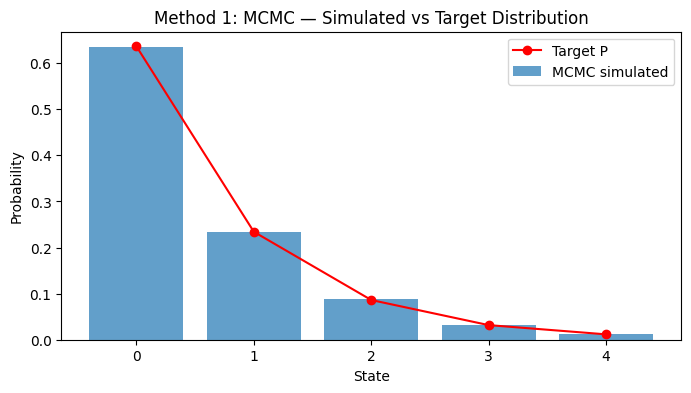


MCMC mean:         0.5509
Theoretical mean:  0.5481


In [ ]:
# Boltzmann-like distribution P(i) ~ exp(-i)
N_states = 5
unnorm = np.exp(-np.arange(N_states))
P_desired = unnorm / unnorm.sum()
observable = np.arange(N_states)

print("Desired distribution P:", np.round(P_desired, 4))

# Acceptance matrix A(i,j) = min(1, P(j)/P(i))
A = np.zeros((N_states, N_states))
for i in range(N_states):
    for j in range(N_states):
        A[i, j] = min(1.0, P_desired[j] / P_desired[i])

# Method 1: MCMC stochastic simulation
n_steps = 200000
state = np.random.randint(0, N_states)
trajectory = []

for _ in range(n_steps):
    # A random state from uniform g
    proposed = np.random.randint(0, N_states)
    p_accept = A[state, proposed]
    u = np.random.uniform(0, 1)
    if u <= p_accept:
        state = proposed
    trajectory.append(state)

trajectory = np.array(trajectory)
counts = np.bincount(trajectory, minlength=N_states)
sim_freq = counts / n_steps

plt.figure(figsize=(8, 4))
plt.bar(range(N_states), sim_freq, alpha=0.7, label='MCMC simulated')
plt.plot(range(N_states), P_desired, 'ro-', label='Target P')
plt.xlabel('State')
plt.ylabel('Probability')
plt.title('Method 1: MCMC — Simulated vs Target Distribution')
plt.legend()
plt.show()

sim_mean = np.dot(sim_freq, observable)
theory_mean = np.dot(P_desired, observable)
print(f"\nMCMC mean:         {sim_mean:.4f}")
print(f"Theoretical mean:  {theory_mean:.4f}")


Final distribution (matrix iteration):
[0.6364 0.2341 0.0861 0.0317 0.0117]
Target distribution:
[0.6364 0.2341 0.0861 0.0317 0.0117]

Matrix mean:       0.5481
Theoretical mean:  0.5481


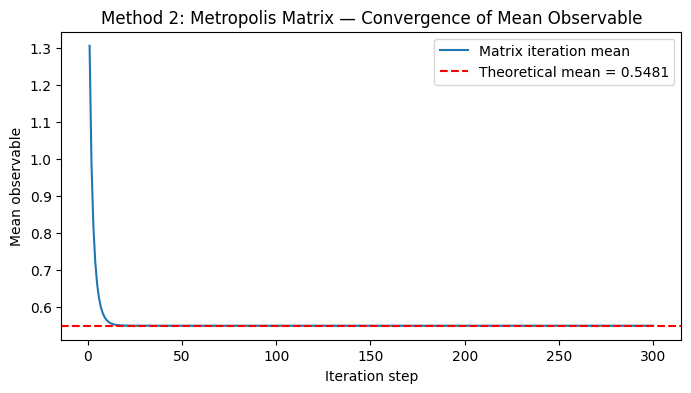

In [42]:
# Method 2: Metropolis transition matrix
# g(i->j) = 1/N (uniform proposal)
g = np.ones((N_states, N_states)) / N_states

T_metro = np.zeros((N_states, N_states))
for i in range(N_states):
    for j in range(N_states):
        if i != j:
            T_metro[i, j] = g[i, j] * A[i, j]
    # Diagonal probability of staying
    T_metro[i, i] = 1.0 - sum(T_metro[i, j] for j in range(N_states) if j != i)

# Matrix iteration starting from uniform
P_iter = np.ones(N_states) / N_states
n_iter = 300
means_iter = []

for _ in range(n_iter):
    P_iter = P_iter @ T_metro
    means_iter.append(np.dot(P_iter, observable))

print("Final distribution (matrix iteration):")
print(np.round(P_iter, 4))
print("Target distribution:")
print(np.round(P_desired, 4))
print(f"\nMatrix mean:       {means_iter[-1]:.4f}")
print(f"Theoretical mean:  {theory_mean:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_iter + 1), means_iter, label='Matrix iteration mean')
plt.axhline(theory_mean, color='red', linestyle='--', label=f'Theoretical mean = {theory_mean:.4f}')
plt.xlabel('Iteration step')
plt.ylabel('Mean observable')
plt.title('Method 2: Metropolis Matrix — Convergence of Mean Observable')
plt.legend()
plt.show()


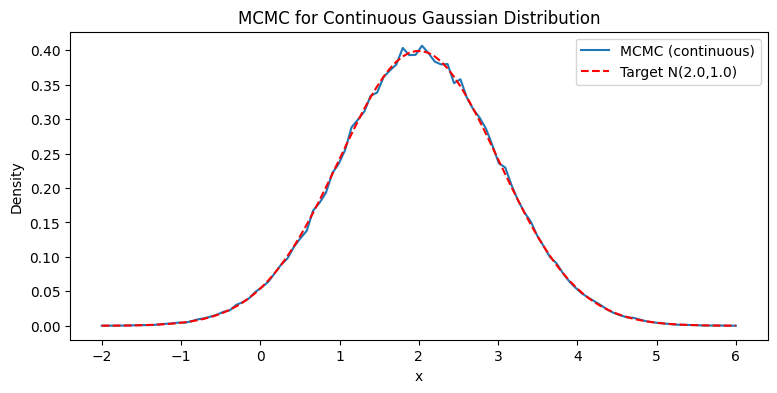

Simulated mean: 2.0044
Target mean:    2.0000


In [43]:
#Continuous distribution: Gaussian with mu=2, sigma=1
# Discretize on a fine grid and apply MCMC
from scipy.stats import norm

N_cont = 100
x_grid = np.linspace(-2, 6, N_cont)
dx = x_grid[1] - x_grid[0]
mu_c, sigma_c = 2.0, 1.0

p_cont = norm.pdf(x_grid, mu_c, sigma_c)
p_cont /= p_cont.sum()  # normalize over grid

# MCMC on continuous grid using Metropolis with uniform proposal
n_steps_c = 500000
state_idx = N_cont // 2  # start in the middle
trajectory_c = []

for _ in range(n_steps_c):
    # Propose a random grid index
    prop_idx = np.random.randint(0, N_cont)
    alpha = min(1.0, p_cont[prop_idx] / p_cont[state_idx])
    if np.random.uniform() <= alpha:
        state_idx = prop_idx
    trajectory_c.append(state_idx)

trajectory_c = np.array(trajectory_c)
counts_c = np.bincount(trajectory_c, minlength=N_cont)
sim_density = counts_c / n_steps_c / dx  # normalize to density

plt.figure(figsize=(9, 4))
plt.plot(x_grid, sim_density, label='MCMC (continuous)')
plt.plot(x_grid, norm.pdf(x_grid, mu_c, sigma_c), 'r--', label=f'Target N({mu_c},{sigma_c})')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('MCMC for Continuous Gaussian Distribution')
plt.legend()
plt.show()

sim_mean_c = np.sum(trajectory_c * dx) / n_steps_c  # rough mean from indices
sim_mean_c = np.mean(x_grid[trajectory_c])
print(f"Simulated mean: {sim_mean_c:.4f}")
print(f"Target mean:    {mu_c:.4f}")


Final mean (matrix iteration): 2.0000
Target mean:                   2.0000


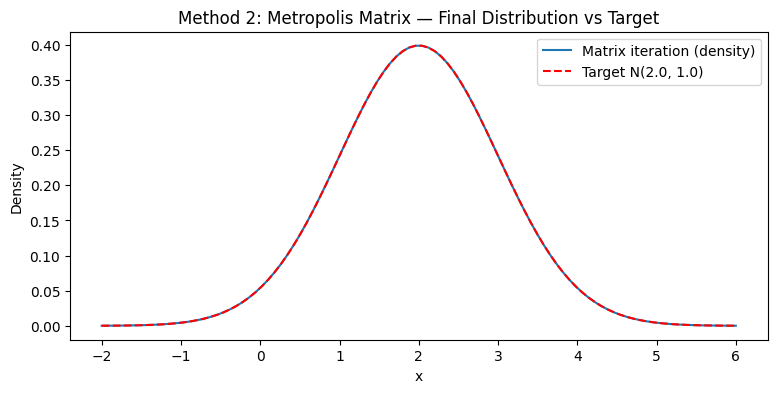

In [46]:
# Method 2: Metropolis Transition Matrix on the discretized Gaussian grid

# Vectorized acceptance matrix: A[i,j] = min(1, p_cont[j] / p_cont[i])
A_cont = np.minimum(1.0, p_cont[np.newaxis, :] / p_cont[:, np.newaxis])

# Build Metropolis transition matrix — uniform proposal g(i,j) = 1/N_cont
g_cont = 1.0 / N_cont
T_metro_cont = g_cont * A_cont          # sets T[i,j] = g * A[i,j] for all i,j

# Fix the diagonal so every row sums to 1
off_diag_sums = T_metro_cont.sum(axis=1) - np.diag(T_metro_cont)
np.fill_diagonal(T_metro_cont, 1.0 - off_diag_sums)

# Matrix iteration, start from uniform distribution
P_iter_cont = np.ones(N_cont) / N_cont
n_iter_cont = 300
means_iter_cont = []

for _ in range(n_iter_cont):
    P_iter_cont = P_iter_cont @ T_metro_cont
    means_iter_cont.append(np.dot(P_iter_cont, x_grid))

print(f"Final mean (matrix iteration): {means_iter_cont[-1]:.4f}")
print(f"Target mean:                   {mu_c:.4f}")

# Final distribution vs target density
plt.figure(figsize=(9, 4))
plt.plot(x_grid, P_iter_cont / dx, label='Matrix iteration (density)')
plt.plot(x_grid, norm.pdf(x_grid, mu_c, sigma_c), 'r--',
         label=f'Target N({mu_c}, {sigma_c})')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Method 2: Metropolis Matrix — Final Distribution vs Target')
plt.legend()
plt.show()

### Exercise 2 Discussion

**Discrete case**

Both methods successfully reproduce the desired Boltzmann-like distribution $P(i) \propto e^{-i}$.

- **Method 1 (MCMC)**: The Metropolis algorithm accepts proposed moves with probability $A(i,j) = \min(1, P(j)/P(i))$. After a sufficient number of steps, the chain converges to the target distribution. The simulated frequencies match the target $P$ closely.

- **Method 2 (Transition matrix)**: By constructing the Metropolis transition matrix $T$ from the acceptance matrix $A$ and the uniform proposal $g$, iterating the distribution vector converges to the target distribution. The convergence of the mean observable is smooth.

Both methods give the same mean observable, confirming that they sample the same distribution.

**Continuous case**

The MCMC method can also be extended to continuous distributions by discretizing the space into a fine grid. The resulting histogram matches the target Gaussian density well, and the simulated mean is close to the theoretical mean $\mu = 2$. The accuracy increases with the number of MCMC steps and the density of the grid.

***The transition matrix method***

The transition matrix $T$ is built over a $100 \times 100$ grid using the acceptance matrix $A_{i,j} = \min(1, P_j/P_i)$ and a uniform proposal. Iterating the distribution vector yields a smooth convergence to the target Gaussian density and $\mu = 2.0$, matching MCMC results. 

While the matrix method is deterministic and smoother, its $O(N^2)$ storage and computation cost make MCMC more efficient for high-dimensional or finely refined grids.

#### Final conclusion

The Metropolis–Hastings algorithm is a powerful method for sampling from any target distribution. The key insight is that it uses an acceptance–rejection step to correct for the difference between the proposal distribution and the target. Both the stochastic simulation and the matrix formulation confirm the same stationary distribution.
